In [1]:
# -*- coding: utf-8 -*-

# Proyecto: Mining Supply Chain Decision Intelligence
# Notebook 01 - Generación de datos sintéticos

### Objetivo
--------
Construir una base de datos sintética, realista y reproducible para un caso de uso
orientado a minería en la Puna / logística remota.

### Este notebook genera la materia prima del proyecto:
- demanda diaria de insumos críticos,
- condiciones climáticas,
- lead time logístico,
- inventario y quiebres de stock,
- órdenes sugeridas por política simple,
- costos operativos y riesgo de atraso.

### La salida de este notebook será usada por:
- notebook de EDA,
- notebook de modelado supervisado,
- notebook de entorno RL,
- notebook de dashboard / app.

### Buenas prácticas aplicadas
--------------------------
- Semilla global para reproducibilidad.
- Código modular y comentado.
- Parámetros centralizados.
- Validaciones básicas de calidad.
- Exportación de datasets en CSV.

### Proyecto fue realizado y ejecutado en Google Colab.

In [2]:
# ===================================================================
# 1) Imports
# ===================================================================

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ===================================================================
# 2) Definicion de rutas relativas.
# ===================================================================

# Definimos el directorio raiz del proyecto dinamicamente.
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

# Estructura de carpetas.
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_DIR / "models"
ASSETS_DIR = PROJECT_DIR / "output"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"

# Creacion automatica de directorios si no existen.
for folder in [DATA_DIR,
               PROCESSED_DIR,
               MODELS_DIR,
               ASSETS_DIR,
               NOTEBOOKS_DIR]:
  folder.mkdir(parents=True, exist_ok=True)

print(f"Proyecto configurado en: {PROJECT_DIR}")
print(f"Directorio RAW: {RAW_DIR}")

Proyecto configurado en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence
Directorio RAW: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw


In [4]:
# ===================================================================
# 3) Configuracion global.
# ===================================================================

@dataclass(frozen=True)
class ProjectConfig:
  """
  Configuracion central del proyecto.
  Mantener todos los parametros aca facilita:
  - reproducibilidad,
  - mantenimiento,
  - experimentacion controlada.
  """
  seed: int = 42
  start_date: str = "2024-01-01"
  end_date: str = "2025-12-31"

  # Entidad del problema.
  num_mines: int = 8
  num_suppliers: int = 5
  num_items: int = 6

  # Escalas del negocio.
  max_stock_capacity: int = 1200
  min_reorder_point: int = 120
  max_reorder_point: int = 420

  # Costos (valores referenciales).
  holding_cost_unit: float = 0.12
  stockout_cost_unit: float = 4.50
  emergency_cost_multiplier: float = 1.65
  transport_cost_base: float = 180.0

  # Umbrales operativos.
  critical_several_level: float = 0.92
  acceptable_service_level: float = 0.97

CFG = ProjectConfig()
np.random.seed(CFG.seed)

In [5]:
# ===================================================================
# 4) Utilidades generales.
# ===================================================================

def clipped_normal(mean: float, std: float, lower: float, upper: float, size=None):
  """
  Genera valores con distribucion normal y recorte en limites.
  Util para variables operativas que no pueden tomar valores extremos.
  """
  values = np.random.normal(mean, std, size=size)
  return np.clip(values, lower, upper)

def seasonal_pattern(day_of_year: np.ndarray, amplitude: float = 1.0, phase_shift: int = 0) -> np.ndarray:
  """
  Patron estacional suave para demanda o clima.
  Usamos una señal sinusoidal para representar temporada alta/baja.
  """
  return amplitude * np.sin(2 * np.pi * (day_of_year + phase_shift) / 365.0)

def ensure_positive_int(series: pd.Series) -> pd.Series:
  """
  Convierte a enteros positivos redondeando y recortando a cero.
  """
  return np.maximum(0, np.round(series).astype(int))

def save_csv(df: pd.DataFrame, path: Path) -> None:
  """
  Guarda un DataFrame en formato CSV y confirma la rura de salida.
  """
  df.to_csv(path, index=False)
  print(f"Guardado: {path}")

In [6]:
# ===================================================================
# 5) Definicion de entidades de negocio.
# ===================================================================

def build_entities(config: ProjectConfig) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
  """
  Crea catalogos base: minas, proveedores, items y calendario.
  Returns
  -------
  mines_df, suppliers_df, items_df, calendar_df
  """
  mines_df = pd.DataFrame({
      "mine_id": [f"M{idx:02d}" for idx in range(1, config.num_mines + 1)],
      "mine_name": [f"Mine_{idx:02d}" for idx in range(1, config.num_mines + 1)],
      "altitude_m": np.random.randint(3200, 4800, size=config.num_mines),
      "distance_km": np.random.randint(80, 620, size=config.num_mines),
      "priority_level": np.random.choice([1, 2, 3], size=config.num_mines, p=[0.25, 0.45, 0.30]),
  })

  suppliers_df = pd.DataFrame({
      "supplier_id": [f"S{idx:02d}" for idx in range(1, config.num_suppliers + 1)],
      "supplier_name": [f"Supplier_{idx:02d}" for idx in range(1, config.num_suppliers + 1)],
      "reliability_score": clipped_normal(0.88, 0.06, 0.70, 0.99, size=config.num_suppliers),
      "base_lead_time_days": np.random.randint(1, 6, size=config.num_suppliers),
  })

  items_df = pd.DataFrame({
      "item_id": [f"I{idx:02d}" for idx in range(1, config.num_items + 1)],
      "item_name": [
          "Diesel",
          "Explosives",
          "Spare_Parts",
          "Lubricants",
          "Reagents",
          "Tires",
      ][:config.num_items],
      "unit_cost": [1.15, 38.0, 24.0, 8.0, 16.5, 210.0][:config.num_items],
      "holding_cost_factor": [0.10, 0.18, 0.14, 0.08, 0.12, 0.16][:config.num_items],
      "criticality": [5, 5, 4, 3, 4, 5][:config.num_items],
      "base_consumption": [28, 6, 12, 9, 7, 2][:config.num_items],
  })

  calendar_df = pd.DataFrame({
      "date": pd.date_range(CFG.start_date, CFG.end_date, freq="D"),
  })
  calendar_df["day_of_year"] = calendar_df["date"].dt.dayofyear
  calendar_df["month"] = calendar_df["date"].dt.month
  calendar_df["year"] = calendar_df["date"].dt.year
  calendar_df["is_weekend"] = calendar_df["date"].dt.dayofweek.isin([5, 6]).astype(int)
  calendar_df["is_month_end"] = calendar_df["date"].dt.is_month_end.astype(int)
  calendar_df["quarter"] = calendar_df["date"].dt.quarter

  return mines_df, suppliers_df, items_df, calendar_df

mines_df, suppliers_df, items_df, calendar_df = build_entities(CFG)

In [7]:
# ===================================================================
# 6) Simulacion climatica y operativa.
# ===================================================================

def simulate_weather(calendar_df: pd.DataFrame) -> pd.DataFrame:
  """
  Simula variables climaticas relevantes para logistica en altura.
  Variables:
  - temperatura
  - viento
  - visibilidad
  - estado del clima
  El objetivo es capturar condiciones adversas tipo "white  wind".
  """
  df = calendar_df.copy()
  doy = df['day_of_year'].to_numpy()

  temp = 5 + seasonal_pattern(doy, amplitude=8, phase_shift=30) + np.random.normal(0, 2.5, len(df))
  wind_speed = np.abs(18 + seasonal_pattern(doy, amplitude=10, phase_shift=180) + np.random.normal(0, 6, len(df)))
  visibility_km = np.clip(18 - 0.5 * wind_speed + np.random.normal(0, 2.2, len(df)), 0.5, 30)

  # Estado del clima con logica simple y util para downstream
  weather_state = np.where(
      (wind_speed > 26) | (visibility_km < 4),
      "white_wind",
      np.where(
          (wind_speed > 18) | (visibility_km < 10),
          "cloudy",
          "clear",
      ),
  )

  df["temperature_c"] = np.round(temp, 2)
  df["wind_speed_kmh"] = np.round(wind_speed, 2)
  df["visibility_km"] = np.round(visibility_km, 2)
  df["weather_state"] = weather_state
  return df

weather_df = simulate_weather(calendar_df)

In [8]:
# ===================================================================
# 7) Generacion de demanda por mina e item.
# ===================================================================
def build_demand_panel(mines_df: pd.DataFrame, items_df: pd.DataFrame, weather_df: pd.DataFrame) -> pd.DataFrame:
  """
  Construye un panel diario de demanda por mina e item.
  El diseño considera:
  - estacionalidad,
  - criticidad del item,
  - distancia de la mina,
  - clima adverso,
  - efecto de fin de mes / fin de semana.
  """
  rows: List[Dict] = []

  merged_calendar = weather_df.copy()

  for _, mine in mines_df.iterrows():
    for _, item in items_df.iterrows():
      base = item["base_consumption"]
      criticality_boost = 1 + (item["criticality"] - 3) * 0.08
      distance_boost = 1 + mine["distance_km"] / 2200
      altitude_boost = 1 + (mine["altitude_m"] - 3200) / 9000

      for _, day in merged_calendar.iterrows():
        seasonal = 1 + 0.18 * seasonal_pattern(day["day_of_year"], amplitude=1.0, phase_shift=45)
        weekend_factor = 0.92 if day["is_weekend"] == 1 else 1.0
        month_end_factor = 1.10 if day["is_month_end"] == 1 else 1.0
        weather_factor = {
            "clear": 1.00,
            "cloudy": 1.04,
            "white_wind": 1.16,
        }[day["weather_state"]]

        # Ruido aleatorio controlado para variabilidad realista.
        noise = np.random.normal(0, base * 0.12)

        demand = (
            base
            * criticality_boost
            * distance_boost
            * altitude_boost
            * seasonal
            * weekend_factor
            * month_end_factor
            * weather_factor
            + noise
        )

        rows.append({
            "date": day["date"],
            "mine_id": mine["mine_id"],
            "mine_name": mine["mine_name"],
            "altitude_m": mine["altitude_m"],
            "distance_km": mine["distance_km"],
            "priority_level": mine["priority_level"],
            "item_id": item["item_id"],
            "item_name": item["item_name"],
            "unit_cost": item["unit_cost"],
            "holding_cost_factor": item["holding_cost_factor"],
            "criticality": item["criticality"],
            "base_consumption": item["base_consumption"],
            "day_of_year": day["day_of_year"],
            "month": day["month"],
            "quarter": day["quarter"],
            "is_weekend": day["is_weekend"],
            "is_month_end": day["is_month_end"],
            "temperature_c": day["temperature_c"],
            "wind_speed_kmh": day["wind_speed_kmh"],
            "visibility_km": day["visibility_km"],
            "weather_state": day["weather_state"],
            "demand_units": max(0, int(round(demand))),
        })

  return pd.DataFrame(rows)

demand_df = build_demand_panel(mines_df, items_df, weather_df)

In [9]:
# ===================================================================
# 8) Lead time, inventario y politica operativa simple
# ===================================================================

def simulate_inventory_policy(
    demand_df: pd.DataFrame,
    suppliers_df: pd.DataFrame,
    config: ProjectConfig,
) -> pd.DataFrame:
  """
  Simula inventario diario y una politica simple de reposicion.
  Esta capa es muy importante porque crea columnas que luego sirven para:
  - modelado supervisado,
  - analisis de negocio,
  - definicion del entorno del Reinforcement Learning.
  La politica aplicada es deliberadamente simple:
  - si el stock proyectado cae por debajo del ROP, se emite una orden,
  - el tamaño del pedido intenta volver al nivel objetivo.
  """
  df = demand_df.copy().sort_values(["mine_id", "item_id", "date"]).reset_index(drop=True)

  # Mapeamos proveedores a minas para simplificar la simulacion.
  mine_to_supplier = {mine_id: np.random.choice(suppliers_df["supplier_id"].values) for mine_id in df["mine_id"].unique()}

  # Parametros por item.
  item_params = (
      df[["item_id", "item_name", "unit_cost", "holding_cost_factor", "criticality"]]
      .drop_duplicates()
      .set_index("item_id")
      .to_dict(orient="index")
  )

  # Estado interno por combinacion mina-item.
  state = {}
  records: List[Dict] = []

  # Conjunto de estados weather para penalizacion
  weather_penalty = {"clear": 0.0, "cloudy": 0.25, "white_wind": 1.0}

  # Indice para acceder a proveedores
  suppliers_idx = suppliers_df.set_index("supplier_id").to_dict(orient="index")

  for (mine_id, item_id), group in df.groupby(["mine_id", "item_id"], sort=False):
    mine_name = group["mine_name"].iloc[0]
    item_name = group["item_name"].iloc[0]
    supplier_id = mine_to_supplier[mine_id]
    supplier = suppliers_idx[supplier_id]

    # Stock inicial proporcional a criticidad y distancia.
    initial_stock = np.random.randint(180, 420)
    current_stock = int(initial_stock)

    # Reorder point y target stock por combinacion.
    rop = int(np.random.randint(config.min_reorder_point, config.max_reorder_point + 1))
    target_stock = int(min(config.max_stock_capacity, rop + np.random.randint(180, 420)))

    # Pedidos en transito: lista de dicts con arrival_date y  quantity.
    pipeline_orders: List[Dict] = []

    for _, row in group.iterrows():
      date = row["date"]
      demand = int(row["demand_units"])
      weather_state = row["weather_state"]

      # Recibimos ordenes que ya llegaron.
      arrivals_today = [o for o in pipeline_orders if o["arrival_date"] == date]
      received_units = int(sum(o["quantity"] for o in arrivals_today))
      pipeline_orders = [o for o in pipeline_orders if o["arrival_date"] != date]

      current_stock += received_units
      stock_before_demand = current_stock

      # Sastifaccion de demanda.
      sales = min(current_stock, demand)
      stockout_units = max(0, demand - sales)
      current_stock -= sales

      # Politica de reposicion.
      projected_stock = current_stock + sum(o["quantity"] for o in pipeline_orders)
      order_qty = 0
      emergency_order = 0

      if projected_stock < rop:
        order_qty = max(0, target_stock - projected_stock)
        order_qty = min(order_qty, config.max_stock_capacity - projected_stock)

        # Emulamos un pedido con lead time variable.
        lead_time = int(
            max(
                1,
                round(
                    supplier["base_lead_time_days"]
                    + np.random.choice([0, 1, 2], p=[0.55, 0.30, 0.15])
                    + weather_penalty[weather_state]
                    + (row["distance_km"] / 350) * 0.15,
                )
            )
        )

        arrival_date = date + pd.Timedelta(days=lead_time)
        pipeline_orders.append({"arrival_date": arrival_date, "quantity": int(order_qty)})

        # Si el clima es muy malo o el stockout es alto, se dispara un pedido urgente.
        if weather_state == "white_wind" and stockout_units > 0:
          emergency_order = int(min(120, max(20, stockout_units * 2)))
          emergency_arrival = date + pd.Timedelta(days=1)
          pipeline_orders.append({"arrival_date": emergency_arrival, "quantity": emergency_order})

      # Costos y metricas operativas.
      holding_cost = current_stock * item_params[item_id]["unit_cost"] * item_params[item_id]["holding_cost_factor"] / 365.0
      stockout_cost = stockout_units * item_params[item_id]["unit_cost"] * config.stockout_cost_unit
      transport_cost = config.transport_cost_base + 0.12 * row["distance_km"] + 1.8 * order_qty + 0.8 * emergency_order
      if emergency_order > 0:
        transport_cost *= config.emergency_cost_multiplier

      service_level = 1.0 if demand == 0 else sales / demand
      fill_rate = 1.0 if demand == 0 else sales / demand
      risk_score = (
          0.40 * (1 - service_level)
          + 0.30 * (1 if weather_state == "white_wind" else 0)
          + 0.20 * min(1.0, stockout_units / max(1, demand))
          + 0.10 * (1 if current_stock < rop else 0)
      )

      records.append({
          **row.to_dict(),
          "supplier_id": supplier_id,
          "initial_stock": initial_stock,
          "stock_before_demand": stock_before_demand,
          "received_units": received_units,
          "sales_units": sales,
          "stockout_units": stockout_units,
          "ending_stock": current_stock,
          "reorder_point": rop,
          "target_stock": target_stock,
          "order_qty": order_qty,
          "emergency_order_qty": emergency_order,
          "pipeline_orders": len(pipeline_orders),
          "holding_cost": round(holding_cost, 2),
          "stockout_cost": round(stockout_cost, 2),
          "transport_cost": round(transport_cost, 2),
          "total_cost": round(holding_cost + stockout_cost + transport_cost, 2),
          "service_level": round(service_level, 4),
          "fill_rate": round(fill_rate, 4),
          "risk_score": round(float(risk_score), 4),
          "is_stockout": int(stockout_units > 0),
          "is_order_day": int(order_qty > 0),
          "is_emergency_day": int(emergency_order > 0),
      })

  return pd.DataFrame(records)

inventory_df = simulate_inventory_policy(demand_df, suppliers_df, CFG)

In [10]:
# ===================================================================
# 9) Features adicionales para analitica y machine learning.
# ===================================================================

def add_analytical_features(df: pd.DataFrame) -> pd.DataFrame:
  """
  Agrega features de negocio utiles para EDA, ML y BI.
  """
  out = df.copy().sort_values(["mine_id", "item_id", "date"]).reset_index(drop=True)

  # Lags y medias moviles por entidad.
  grouped = out.groupby(["mine_id", "item_id"], sort=False)
  out["demand_lag_1"] = grouped["demand_units"].shift(1)
  out["demand_lag_7"] = grouped["demand_units"].shift(7)
  out["rolling_demand_7"] = grouped["demand_units"].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
  out["rolling_demand_30"] = grouped["demand_units"].transform(lambda s: s.shift(1).rolling(30, min_periods=1).mean())
  out["rolling_stockout_30"] = grouped["is_stockout"].transform(lambda s: s.shift(1).rolling(30, min_periods=1).mean())
  out["rolling_service_30"] = grouped["service_level"].transform(lambda s: s.shift(1).rolling(30, min_periods=1).mean())
  out["days_since_order"] = grouped["is_order_day"].cumsum()
  out["inventory_turnover_proxy"] = np.where(out["ending_stock"] > 0, out["sales_units"] / out["ending_stock"], 0)

  # Rellenamos valores faltantes generados por lags.
  lag_cols = ["demand_lag_1", "demand_lag_7", "rolling_demand_7", "rolling_demand_30", "rolling_stockout_30", "rolling_service_30"]
  for col in lag_cols:
    out[col] = out[col].fillna(0)

  return out

final_df = add_analytical_features(inventory_df)

In [11]:
# ===================================================================
# 10) Validaciones de calidad de datos.
# ===================================================================

def run_data_quality_checks(df: pd.DataFrame) -> pd.DataFrame:
  """
  Ejecuta chequeos simples de calidad y devuelve un reporte.
  """
  checks = []

  checks.append({"check": "rows",
                 "value": len(df), "status": "ok" if len(df) > 0 else "fail"})
  checks.append({"check": "null_values",
                 "value": int(df.isna().sum().sum()),
                 "status": "ok" if df.isna().sum().sum() == 0 else "warn"})
  checks.append({"check": "negative_demand",
                 "value": int((df["demand_units"] < 0).sum()),
                 "status": "ok" if (df["demand_units"] < 0).sum() == 0 else "fail"})
  checks.append({"check": "negative_stock",
                 "value": int((df["ending_stock"] < 0).sum()),
                 "status": "ok" if (df["ending_stock"] < 0).sum() == 0 else "fail"})
  checks.append({"check": "service_level_range",
                 "value": int(((df["service_level"] < 0) | (df["service_level"] > 1)).sum()),
                 "status": "ok" if (((df["service_level"] < 0) | (df["service_level"] > 1)).sum() == 0) else "fail"})
  checks.append({"check": "risk_score_range",
                 "value": int(((df["risk_score"] < 0) | (df["risk_score"] > 1)).sum()),
                 "status": "ok" if (((df["risk_score"] > 1)).sum() == 0) else "fail"})

  return pd.DataFrame(checks)

quality_report = run_data_quality_checks(final_df)
print("Reporte de calidad de datos:\n")
print(quality_report.to_string(index=False))

Reporte de calidad de datos:

              check  value status
               rows  35088     ok
        null_values      0     ok
    negative_demand      0     ok
     negative_stock      0     ok
service_level_range      0     ok
   risk_score_range      0     ok


In [12]:
# ===================================================================
# 11) Resumen ejecutivo del dataset.
# ===================================================================

def build_executive_summary(df: pd.DataFrame) -> pd.DataFrame:
  """
  Calcula indicadores de negocio para documentar el dataset.
  """
  summary = pd.DataFrame({
      "metric": [
          "rows",
          "date_start",
          "date_end",
          "mine",
          "items",
          "avg_demand",
          "avg_stockout_rate",
          "avg_service_level",
          "total_cost",
          "avg_risk_score",
      ],
      "value": [
          len(df),
          df["date"].min(),
          df["date"].max(),
          df["mine_id"].nunique(),
          df["item_id"].nunique(),
          round(df["demand_units"].mean(), 2),
          round(df["is_stockout"].mean(), 4),
          round(df["service_level"].mean(), 4),
          round(df["total_cost"].sum(), 2),
          round(df["risk_score"].mean(), 4),
      ],
  })
  return summary

summary_df = build_executive_summary(final_df)
print("\nResumen ejecutivo del dataset:\n")
print(summary_df.to_string(index=False))


Resumen ejecutivo del dataset:

           metric               value
             rows               35088
       date_start 2024-01-01 00:00:00
         date_end 2025-12-31 00:00:00
             mine                   8
            items                   6
       avg_demand               15.76
avg_stockout_rate              0.0064
avg_service_level               0.995
       total_cost          9090487.67
   avg_risk_score              0.0931


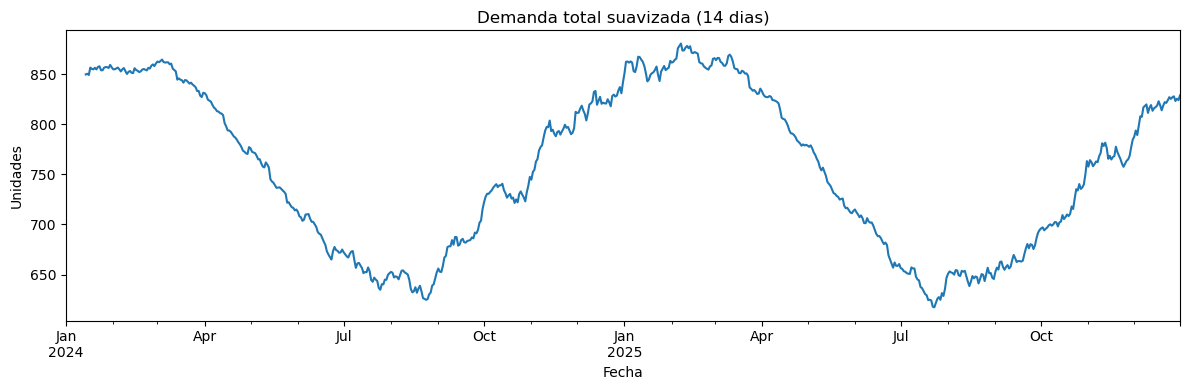

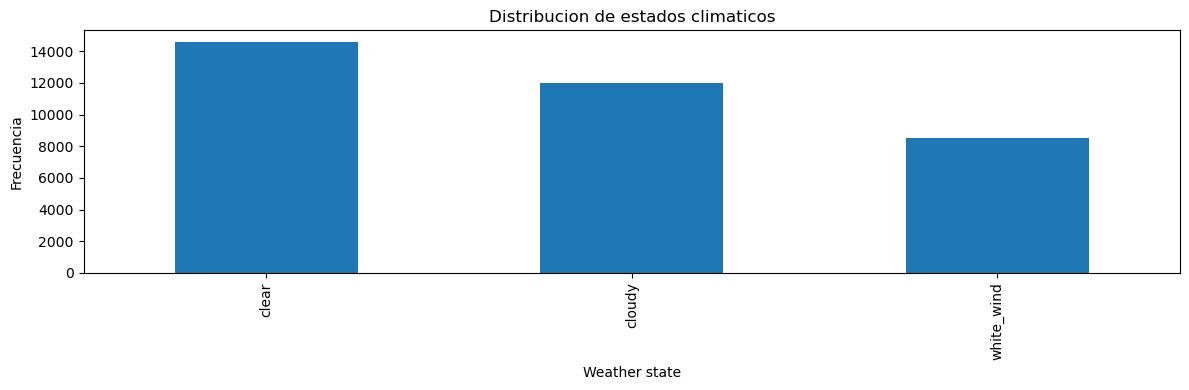

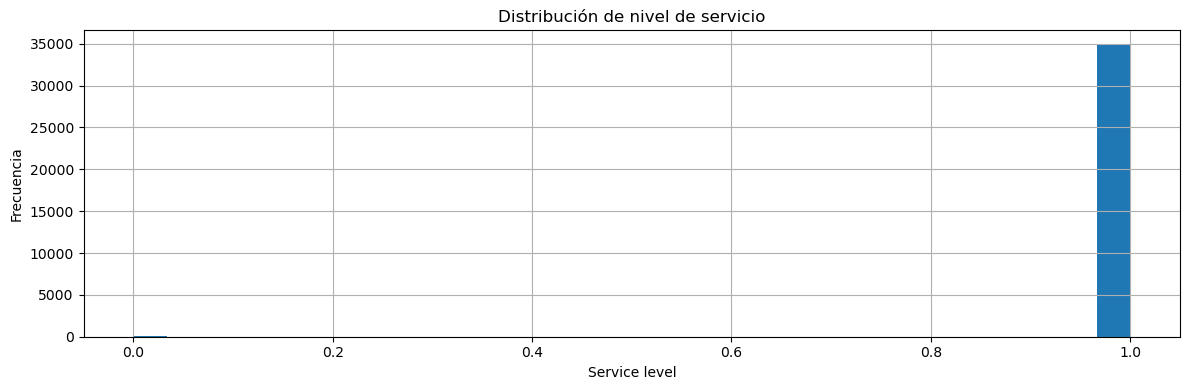

In [13]:
# ===================================================================
# 12) Visualizaciones rapidas de control.
# ===================================================================

plt.figure(figsize=(12, 4))
final_df.groupby("date")["demand_units"].sum().rolling(14).mean().plot()
plt.title("Demanda total suavizada (14 dias)")
plt.xlabel("Fecha")
plt.ylabel("Unidades")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
final_df["weather_state"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribucion de estados climaticos")
plt.xlabel("Weather state")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
final_df["service_level"].hist(bins=30)
plt.title("Distribución de nivel de servicio")
plt.xlabel("Service level")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [14]:
# ===================================================================
# 13) Exportacion de datasets.
# ===================================================================

# Catalogos base.
mines_path = RAW_DIR / "mines.csv"
suppliers_path = RAW_DIR / "suppliers.csv"
items_path = RAW_DIR / "items.csv"
calendar_path = RAW_DIR / "calendar_weather.csv"

# Dataset principal y dataset analitico.
raw_path = RAW_DIR / "inventory_raw_panel.csv"
final_path = RAW_DIR / "inventory_analytics_panel.csv"
quality_path = RAW_DIR / "data_quality_report.csv"
summary_path = RAW_DIR / "executive_summary.csv"

save_csv(mines_df, mines_path)
save_csv(suppliers_df, suppliers_path)
save_csv(items_df, items_path)
save_csv(weather_df, calendar_path)
save_csv(demand_df, raw_path)
save_csv(final_df, final_path)
save_csv(quality_report, quality_path)
save_csv(summary_df, summary_path)

print("\nArchivos guardados correctamente en RAW_DIR.")


Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\mines.csv
Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\suppliers.csv
Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\items.csv
Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\calendar_weather.csv
Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\inventory_raw_panel.csv
Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\inventory_analytics_panel.csv
Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\data_quality_report.csv
Guardado: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw\executive_summary.csv

Arch

In [15]:
# ===================================================================
# 12) Vista previa del dataset final.
# ===================================================================

print("\nVista previa del dataset final:")
print(final_df.head(10).to_string(index=False))


Vista previa del dataset final:
      date mine_id mine_name  altitude_m  distance_km  priority_level item_id item_name  unit_cost  holding_cost_factor  criticality  base_consumption  day_of_year  month  quarter  is_weekend  is_month_end  temperature_c  wind_speed_kmh  visibility_km weather_state  demand_units supplier_id  initial_stock  stock_before_demand  received_units  sales_units  stockout_units  ending_stock  reorder_point  target_stock  order_qty  emergency_order_qty  pipeline_orders  holding_cost  stockout_cost  transport_cost  total_cost  service_level  fill_rate  risk_score  is_stockout  is_order_day  is_emergency_day  demand_lag_1  demand_lag_7  rolling_demand_7  rolling_demand_30  rolling_stockout_30  rolling_service_30  days_since_order  inventory_turnover_proxy
2024-01-01     M01   Mine_01        4326          546               1     I01    Diesel       1.15                  0.1            5                28            1      1        1           0             0       

# Variables clave disponibles para notebooks posteriores.

### Columnas especialmente utiles para proximos pasos:

Prediccion supervisada:
- demand_units,
- service_level,
- total_cost,
- risk_score,
- stockout_units,
- weather_state,
- distance_km,
- altitude_m,
- rolling_demand_7,
- rolling_demand_30,
- rolling_service_30

Refuerzo:
- estado: ending_stock, demand forecast, weather_state, lead time proxy, risk_score;
- accion: order_qty o decision de reposicion,
- recompensa: - total_cost + bonus por service_level alto

Dashboard:
- total_cost,
- service_level,
- fill_rate,
- is_stockout,
- is_emergency_day,
- risk_score,
- demand_units,
- order_qty